# Bivariate Global Map: |∇b|² × Turner Angle

This notebook loads the co-located output from `build_v3` and creates
a bivariate global map where each front is colored by **|∇b|²** and
**Turner angle** simultaneously.

The color scheme uses a 2×2 grid:
- **Turner angle < 0** → blue hues (salinity-dominated)
- **Turner angle > 0** → red hues (temperature-dominated)
- **Low |∇b|²** → lighter shade
- **High |∇b|²** → darker shade

**Sections:**
1. Configuration
2. Data Loading & Inspection
3. Bivariate Color Mapping Functions
4. Plotting Functions
5. Generate Bivariate Map

---
## 1. Configuration

Edit this cell to change input paths, variables, and plotting options.

In [20]:
import os
from pathlib import Path

# ─── DATA PATHS ───────────────────────────────────────────────────────────────
OGCM_ROOT = os.environ.get('OS_OGCM', '/mnt/tank/Oceanography/data/OGCM/')

# build_v3 co-located output directory
RESULTS_DIR = Path(OGCM_ROOT) / 'LLC' / 'Fronts' / 'V3' / '20121109_120000'

# Timestamp of the snapshot (ISO 8601 format for viz_loaders)
TIME_STR = '2012-11-09T12:00:00'

# Run tag (suffix on output filenames)
RUN_TAG = 'v3_bin_D'

# LLC coordinate file (None → default)
COORDS_FILE = None

# ─── VARIABLE SELECTION ───────────────────────────────────────────────────────
GRADB2_BASE  = 'gradb2'        # |∇b|²  (buoyancy gradient squared)
TURNER_BASE  = 'turner_angle'  # Turner angle in degrees

# Display labels for axes / titles
VAR1_LABEL = r'$|\nabla b|^2$'  # x-axis: gradb2
VAR2_LABEL = r'$Tu_h$ (°)'      # y-axis: Turner angle

# Summary statistic: 'mean', 'median', or 'p90'
STATISTIC = 'mean'

# ─── BIVARIATE BINNING ────────────────────────────────────────────────────────
# Fixed at 2×2:  gradb2 (low/high) × Turner angle (negative/positive)
N_BINS = 2

# Percentile clipping for gradb2 bin edge (removes outlier tails)
CLIP_PERCENTILE = 2  # clip bottom/top N%

# ─── MAP OPTIONS ──────────────────────────────────────────────────────────────
PROJECTION = 'Robinson'
MARKER_SIZE = 1.0

USE_SPATIAL_BINNING = True
SPATIAL_BIN_DEG = 2

# ─── OUTPUT ────────────────────────────────────────────────────────────────────
SAVE_DIR = Path('.') / 'figures'
SAVE_DPI = 200

---
## 2. Data Loading & Inspection

In [21]:
import sys
import numpy as np
import pandas as pd

from fronts.properties.viz_loaders import (
    load_global_front_results,
    load_colocation_table,
    load_geometry_table,
    merge_geometry_colocation,
)

In [22]:
# Load all front results (geometry + colocation merged, coords aligned)
results = load_global_front_results(
    results_dir=RESULTS_DIR,
    time_str=TIME_STR,
    run_tag=RUN_TAG,
    coords_file=COORDS_FILE,
)

df_enriched    = results['df_enriched']
lat_global     = results['lat_global']
lon_global     = results['lon_global']
labeled_global = results['labeled_global']
metadata       = results['metadata']

print(f"Enriched DataFrame: {df_enriched.shape[0]:,} fronts, {df_enriched.shape[1]} columns")
print(f"Grid shape: {lat_global.shape}")

Loading metadata from /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V3/20121109_120000/metadata_20121109T12_00_00_v3_bin_D.json
Loading geometry table from /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V3/20121109_120000/global_front_geometry_20121109T12_00_00_v3_bin_D.parquet
Loading colocation table from /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V3/20121109_120000/front_properties_20121109T12_00_00_v3_bin_D.parquet
Enriched DataFrame: 136,490 fronts, 105 columns
Grid shape: (12960, 17280)


In [23]:
# ─── INSPECT AVAILABLE COLUMNS ────────────────────────────────────────────────
print("All columns in df_enriched:")
print("-" * 50)
for col in sorted(df_enriched.columns):
    print(f"  {col}")
print(f"\nTotal: {len(df_enriched.columns)} columns")

All columns in df_enriched:
--------------------------------------------------
  Eta_mean
  Eta_median
  Eta_std
  SIarea_mean
  SIarea_median
  SIarea_std
  Salt_mean
  Salt_median
  Salt_std
  Theta_mean
  Theta_median
  Theta_std
  U_mean
  U_median
  U_std
  V_mean
  V_median
  V_std
  W_mean
  W_median
  W_std
  centroid_lat
  centroid_lon
  coriolis_f_mean
  coriolis_f_median
  coriolis_f_std
  curvature_direction
  divergence_mean
  divergence_median
  divergence_std
  flabel
  frontogenesis_ageo_mean
  frontogenesis_ageo_median
  frontogenesis_ageo_std
  frontogenesis_geo_mean
  frontogenesis_geo_median
  frontogenesis_geo_std
  frontogenesis_tendency_mean
  frontogenesis_tendency_median
  frontogenesis_tendency_std
  gradb2_mean
  gradb2_median
  gradb2_std
  gradeta2_mean
  gradeta2_median
  gradeta2_std
  gradrho2_mean
  gradrho2_median
  gradrho2_std
  gradsalt2_mean
  gradsalt2_median
  gradsalt2_std
  gradtheta2_mean
  gradtheta2_median
  gradtheta2_std
  label
  lat_max


In [24]:
# ─── RESOLVE COLUMN NAMES ─────────────────────────────────────────────────────

def resolve_column(df, base_name, statistic):
    """Find the best matching column for `base_name` with `statistic` suffix.

    Tries: '{base}_{stat}', '{base}_median', '{base}_mean', '{base}'
    Returns the column name or raises KeyError with helpful message.
    """
    candidates = [
        f"{base_name}_{statistic}",
        f"{base_name}_median",
        f"{base_name}_mean",
        base_name,
    ]
    for c in candidates:
        if c in df.columns:
            return c

    matches = [c for c in df.columns if base_name in c]
    raise KeyError(
        f"Could not find column for '{base_name}' with statistic '{statistic}'.\n"
        f"Tried: {candidates}\n"
        f"Partial matches in DataFrame: {matches}\n"
        f"→ Update GRADB2_BASE / TURNER_BASE in the configuration cell."
    )


gradb2_col = resolve_column(df_enriched, GRADB2_BASE, STATISTIC)
turner_col = resolve_column(df_enriched, TURNER_BASE, STATISTIC)

print(f"|∇b|²    : {GRADB2_BASE!r:20s} →  column '{gradb2_col}'")
print(f"Turner angle : {TURNER_BASE!r:20s} →  column '{turner_col}'")

for c in [gradb2_col, turner_col]:
    vals = df_enriched[c].dropna()
    print(f"\n  {c}: n={len(vals):,}, "
          f"min={vals.min():.3e}, median={vals.median():.3e}, "
          f"max={vals.max():.3e}")

|∇b|²    : 'gradb2'             →  column 'gradb2_mean'
Turner angle : 'turner_angle'       →  column 'turner_angle_mean'

  gradb2_mean: n=136,490, min=2.324e-17, median=9.699e-15, max=1.515e-10

  turner_angle_mean: n=136,490, min=-8.891e+01, median=-8.755e+00, max=8.996e+01


In [25]:
# ─── EXTRACT THE TWO ARRAYS ───────────────────────────────────────────────────
values_gradb2 = df_enriched[gradb2_col].values.astype(np.float64)
values_turner = df_enriched[turner_col].values.astype(np.float64)

print(f"|∇b|²  : {np.isfinite(values_gradb2).sum():,} finite values")
print(f"Turner  : {np.isfinite(values_turner).sum():,} finite values")

|∇b|²  : 136,490 finite values
Turner  : 136,490 finite values


---
## 3. Bivariate Color Mapping Functions

The 2×2 color scheme is designed with physical meaning:

| | **Tu < 0** (salinity-dominated) | **Tu > 0** (temperature-dominated) |
|---|---|---|
| **High |∇b|²** | dark blue | dark red |
| **Low |∇b|²** | light blue | light red/pink |

- The **Turner angle axis** is split at 0° (fixed, physically meaningful boundary).
- The **|∇b|² axis** is split at the median (quantile-based), separating
  weak vs. strong fronts.
- Lighter shades = weaker fronts, darker shades = stronger fronts.

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import binned_statistic_2d


def make_turner_gradb2_colormap():
    """Create the 2×2 bivariate color grid for Turner angle × |∇b|².

    Layout (indexed as color_grid[gradb2_bin, turner_bin]):
        gradb2_bin=0 (low):  [light blue,  light red ]
        gradb2_bin=1 (high): [dark blue,   dark red  ]
        turner_bin=0: Tu < 0 (negative, salinity-dominated)
        turner_bin=1: Tu > 0 (positive, temperature-dominated)

    Returns
    -------
    color_grid : np.ndarray, shape (2, 2, 3)
        RGB colors indexed as [gradb2_bin, turner_bin, rgb].
    """
    color_grid = np.zeros((2, 2, 3))

    # Turner < 0 → blue hues;  Turner > 0 → red hues
    # Low gradb2 → lighter;    High gradb2 → darker
    color_grid[0, 0] = [0.65, 0.74, 0.86]   # light blue  (low |∇b|², Tu < 0)
    color_grid[1, 0] = [0.15, 0.25, 0.55]   # dark blue   (high |∇b|², Tu < 0)
    color_grid[0, 1] = [0.89, 0.65, 0.63]   # light red   (low |∇b|², Tu > 0)
    color_grid[1, 1] = [0.70, 0.13, 0.13]   # dark red    (high |∇b|², Tu > 0)

    return color_grid


def assign_turner_gradb2_bins(gradb2_vals, turner_vals, clip_pct=2):
    """Assign each front to one of the 2×2 bivariate bins.

    Turner angle axis: fixed split at 0° (physically meaningful).
      bin 0 = Tu < 0 (negative, salinity-dominated)
      bin 1 = Tu ≥ 0 (positive, temperature-dominated)

    |∇b|² axis: split at the median of valid values.
      bin 0 = below median (weak fronts)
      bin 1 = above median (strong fronts)

    Parameters
    ----------
    gradb2_vals : array-like
        Per-front |∇b|² values.
    turner_vals : array-like
        Per-front Turner angle in degrees.
    clip_pct : float
        Percentile clipping for |∇b|² (removes outlier tails).

    Returns
    -------
    bins_gradb2, bins_turner : np.ndarray of int
        Bin index (0 or 1) for each front. -1 where data is NaN/invalid.
    gradb2_edges : np.ndarray, shape (3,)
        [min, median, max] for |∇b|² (for legend labels).
    turner_edges : np.ndarray, shape (3,)
        Fixed at [-90, 0, 90].
    """
    gb2 = np.asarray(gradb2_vals, dtype=np.float64)
    tu  = np.asarray(turner_vals, dtype=np.float64)

    valid = np.isfinite(gb2) & np.isfinite(tu)

    # ── Turner angle: fixed split at 0 ──────────────────────────────────
    bins_turner = np.full(len(tu), -1, dtype=int)
    bins_turner[valid & (tu <  0)] = 0   # negative → salinity-dominated
    bins_turner[valid & (tu >= 0)] = 1   # positive → temperature-dominated
    turner_edges = np.array([-90.0, 0.0, 90.0])

    # ── |∇b|²: split at median of valid values ──────────────────────────
    gb2_valid = gb2[valid]
    lo = np.percentile(gb2_valid, clip_pct)
    hi = np.percentile(gb2_valid, 100 - clip_pct)
    median_gb2 = np.median(gb2_valid)

    bins_gradb2 = np.full(len(gb2), -1, dtype=int)
    bins_gradb2[valid & (gb2 <  median_gb2)] = 0  # low
    bins_gradb2[valid & (gb2 >= median_gb2)] = 1  # high
    gradb2_edges = np.array([lo, median_gb2, hi])

    return bins_gradb2, bins_turner, gradb2_edges, turner_edges

---
## 4. Plotting Functions

In [27]:
def plot_turner_gradb2_legend(color_grid, gradb2_edges, turner_edges,
                               figsize=(5, 4)):
    """Plot the 2×2 bivariate legend for Turner angle × |∇b|².

    Parameters
    ----------
    color_grid : np.ndarray, shape (2, 2, 3)
        From make_turner_gradb2_colormap().
    gradb2_edges : np.ndarray, shape (3,)
        [min, median, max] of |∇b|².
    turner_edges : np.ndarray, shape (3,)
        [-90, 0, 90].
    figsize : tuple
        Figure size.

    Returns
    -------
    fig, ax
    """
    fig, ax = plt.subplots(figsize=figsize)

    cell_labels = [
        ['low $|\\nabla b|^2$\nTu < 0\n(salinity)',
         'low $|\\nabla b|^2$\nTu > 0\n(temperature)'],
        ['high $|\\nabla b|^2$\nTu < 0\n(salinity)',
         'high $|\\nabla b|^2$\nTu > 0\n(temperature)'],
    ]

    for i in range(2):       # gradb2 (y-axis: 0=low=bottom, 1=high=top)
        for j in range(2):   # turner (x-axis: 0=negative=left, 1=positive=right)
            rect = mpatches.FancyBboxPatch(
                (j, i), 1, 1,
                boxstyle='round,pad=0.03',
                facecolor=color_grid[i, j],
                edgecolor='white', linewidth=2,
            )
            ax.add_patch(rect)

            # Choose text color for readability (white on dark, black on light)
            lum = 0.299 * color_grid[i, j, 0] + 0.587 * color_grid[i, j, 1] + 0.114 * color_grid[i, j, 2]
            tc = 'white' if lum < 0.5 else 'black'
            ax.text(j + 0.5, i + 0.5, cell_labels[i][j],
                    ha='center', va='center', fontsize=11, color=tc,
                    fontweight='bold')

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_aspect('equal')

    # Axis labels and ticks
    def _fmt(v):
        if abs(v) < 0.01 or abs(v) >= 1e4:
            return f"{v:.1e}"
        return f"{v:.3g}"

    # X-axis: Turner angle edges
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([f"{turner_edges[0]:.0f}°",
                        f"{turner_edges[1]:.0f}°",
                        f"{turner_edges[2]:.0f}°"],
                       fontsize=9)
    ax.set_xlabel(r'$Tu_h$ (°)  →', fontsize=11, fontweight='bold')

    # Y-axis: gradb2 edges
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels([_fmt(gradb2_edges[0]),
                        _fmt(gradb2_edges[1]),
                        _fmt(gradb2_edges[2])],
                       fontsize=9)
    ax.set_ylabel(r'$|\nabla b|^2$  →', fontsize=11, fontweight='bold')

    ax.set_title('Bivariate Legend', fontsize=12)
    fig.tight_layout()
    return fig, ax


def plot_turner_gradb2_map(
    df, bins_gradb2, bins_turner, color_grid,
    lat_col='centroid_lat', lon_col='centroid_lon',
    projection='Robinson',
    marker_size=1.0,
    use_spatial_binning=False,
    spatial_bin_deg=2,
    title=None,
    figsize=(18, 9),
):
    """Plot fronts on a global map colored by the 2×2 bivariate scheme.

    Parameters
    ----------
    df : pd.DataFrame
        Enriched front table with lat/lon columns.
    bins_gradb2, bins_turner : np.ndarray of int
        Bin indices (0 or 1) from assign_turner_gradb2_bins().
    color_grid : np.ndarray, shape (2, 2, 3)
        From make_turner_gradb2_colormap().
    lat_col, lon_col : str
        Column names for front latitude/longitude.
    projection : str
        Cartopy projection name.
    marker_size : float
        Scatter marker size.
    use_spatial_binning : bool
        If True, aggregate into spatial bins (dominant category per cell).
    spatial_bin_deg : float
        Size of spatial bins in degrees.
    title : str, optional
        Custom title. Auto-generated if None.
    figsize : tuple
        Figure size.

    Returns
    -------
    fig, ax
    """
    proj_map = {
        'Robinson': ccrs.Robinson(),
        'Mollweide': ccrs.Mollweide(),
        'PlateCarree': ccrs.PlateCarree(),
    }
    proj = proj_map.get(projection, ccrs.Robinson())
    tfm = ccrs.PlateCarree()

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': proj})
    ax.set_global()

    # Filter to valid fronts (both bins assigned)
    valid = (bins_gradb2 >= 0) & (bins_turner >= 0)
    lats = df[lat_col].values[valid]
    lons = df[lon_col].values[valid]
    bg = bins_gradb2[valid]
    bt = bins_turner[valid]

    # Color each front: color_grid[gradb2_bin, turner_bin]
    front_colors = color_grid[bg, bt]

    if use_spatial_binning:
        # ── Spatially bin: most common 2×2 category per cell ──────────
        n_bv = 2  # 2×2 grid
        biv_idx = bg * n_bv + bt  # flatten: 0,1,2,3

        n_lat = int(180 / spatial_bin_deg)
        n_lon = int(360 / spatial_bin_deg)
        lat_edges = np.linspace(-90, 90, n_lat + 1)
        lon_edges = np.linspace(-180, 180, n_lon + 1)

        from scipy.stats import binned_statistic_2d
        stat_result = binned_statistic_2d(
            lats, lons, biv_idx.astype(float),
            statistic='mean',
            bins=[lat_edges, lon_edges],
            expand_binnumbers=True,
        )

        n_total_bv = n_bv * n_bv  # 4 categories
        count_grid = np.zeros((n_lat, n_lon), dtype=int)
        lat_bin_idx = np.clip(stat_result.binnumber[0] - 1, 0, n_lat - 1)
        lon_bin_idx = np.clip(stat_result.binnumber[1] - 1, 0, n_lon - 1)

        cat_counts = np.zeros((n_lat, n_lon, n_total_bv), dtype=int)
        for k in range(len(lats)):
            li, lj = lat_bin_idx[k], lon_bin_idx[k]
            count_grid[li, lj] += 1
            cat_counts[li, lj, int(biv_idx[k])] += 1

        mode_idx = np.argmax(cat_counts, axis=2)
        has_data = count_grid > 0

        # Plot colored rectangles
        for i in range(n_lat):
            for j in range(n_lon):
                if has_data[i, j]:
                    cat = mode_idx[i, j]
                    bt_cell = cat % n_bv   # turner bin
                    bg_cell = cat // n_bv  # gradb2 bin
                    c = color_grid[bg_cell, bt_cell]
                    ax.fill_between(
                        [lon_edges[j], lon_edges[j+1]],
                        lat_edges[i], lat_edges[i+1],
                        color=c, transform=tfm, zorder=1,
                    )

        n_plotted = has_data.sum()
        method_str = f'{spatial_bin_deg}°×{spatial_bin_deg}° bins, mode category'

    else:
        # ── Scatter each front centroid ──────────────────────────────
        ax.scatter(
            lons, lats,
            c=front_colors,
            s=marker_size,
            transform=tfm,
            zorder=1,
            rasterized=True,
            edgecolors='none',
        )
        n_plotted = valid.sum()
        method_str = 'front centroids'

    # ── Map features (Turner_Angle_Global_Viz.ipynb style) ─────────────────
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k',    zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.2, color='gray', zorder=3)
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray',
                 alpha=0.5, linestyle='--')

    if title is None:
        title = (
            r'Bivariate Front Map: $|\nabla b|^2$ × $Tu_h$' + '\n'
            f'({n_plotted:,} {method_str})'
        )
    ax.set_title(title, fontsize=12, pad=10)

    fig.tight_layout()
    return fig, ax

---
## 5. Generate Bivariate Map

In [28]:
# ─── COMPUTE 2×2 BIVARIATE BINS ──────────────────────────────────────────────
bins_gradb2, bins_turner, gradb2_edges, turner_edges = assign_turner_gradb2_bins(
    values_gradb2, values_turner, clip_pct=CLIP_PERCENTILE
)

# Build the 2×2 color grid
color_grid = make_turner_gradb2_colormap()

# Report
valid_mask = (bins_gradb2 >= 0) & (bins_turner >= 0)
print(f"Valid fronts: {valid_mask.sum():,} / {len(bins_gradb2):,}")
print(f"\n|∇b|² edges: {gradb2_edges}  (split at median)")
print(f"Turner edges:  {turner_edges}  (fixed at 0°)")

# 2×2 counts
print(f"\nBivariate bin counts (2×2):")
print(f"{'':>20s}  Tu < 0 (blue)  |  Tu ≥ 0 (red)")
print(f"-" * 55)
for i, gb_label in enumerate(['Low  |∇b|²', 'High |∇b|²']):
    n_neg = ((bins_gradb2 == i) & (bins_turner == 0)).sum()
    n_pos = ((bins_gradb2 == i) & (bins_turner == 1)).sum()
    shade = 'light' if i == 0 else 'dark'
    print(f"  {gb_label} ({shade:>5s}):  {n_neg:>10,}     |  {n_pos:>10,}")

Valid fronts: 136,490 / 136,490

|∇b|² edges: [4.39586405e-16 9.69914204e-15 5.38994445e-13]  (split at median)
Turner edges:  [-90.   0.  90.]  (fixed at 0°)

Bivariate bin counts (2×2):
                      Tu < 0 (blue)  |  Tu ≥ 0 (red)
-------------------------------------------------------
  Low  |∇b|² (light):      34,154     |      34,091
  High |∇b|² ( dark):      40,108     |      28,137


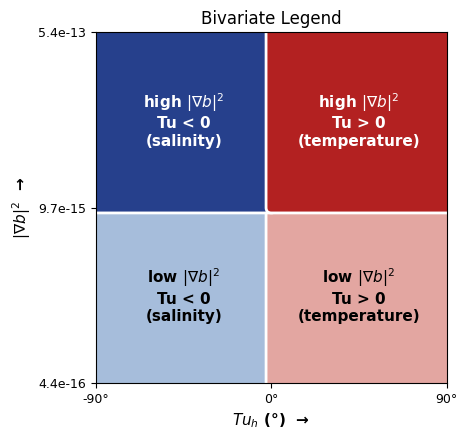

In [29]:
# ─── PLOT 1: BIVARIATE LEGEND ─────────────────────────────────────────────────
fig_legend, ax_legend = plot_turner_gradb2_legend(
    color_grid, gradb2_edges, turner_edges,
    figsize=(5.5, 4.5),
)
plt.show()

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


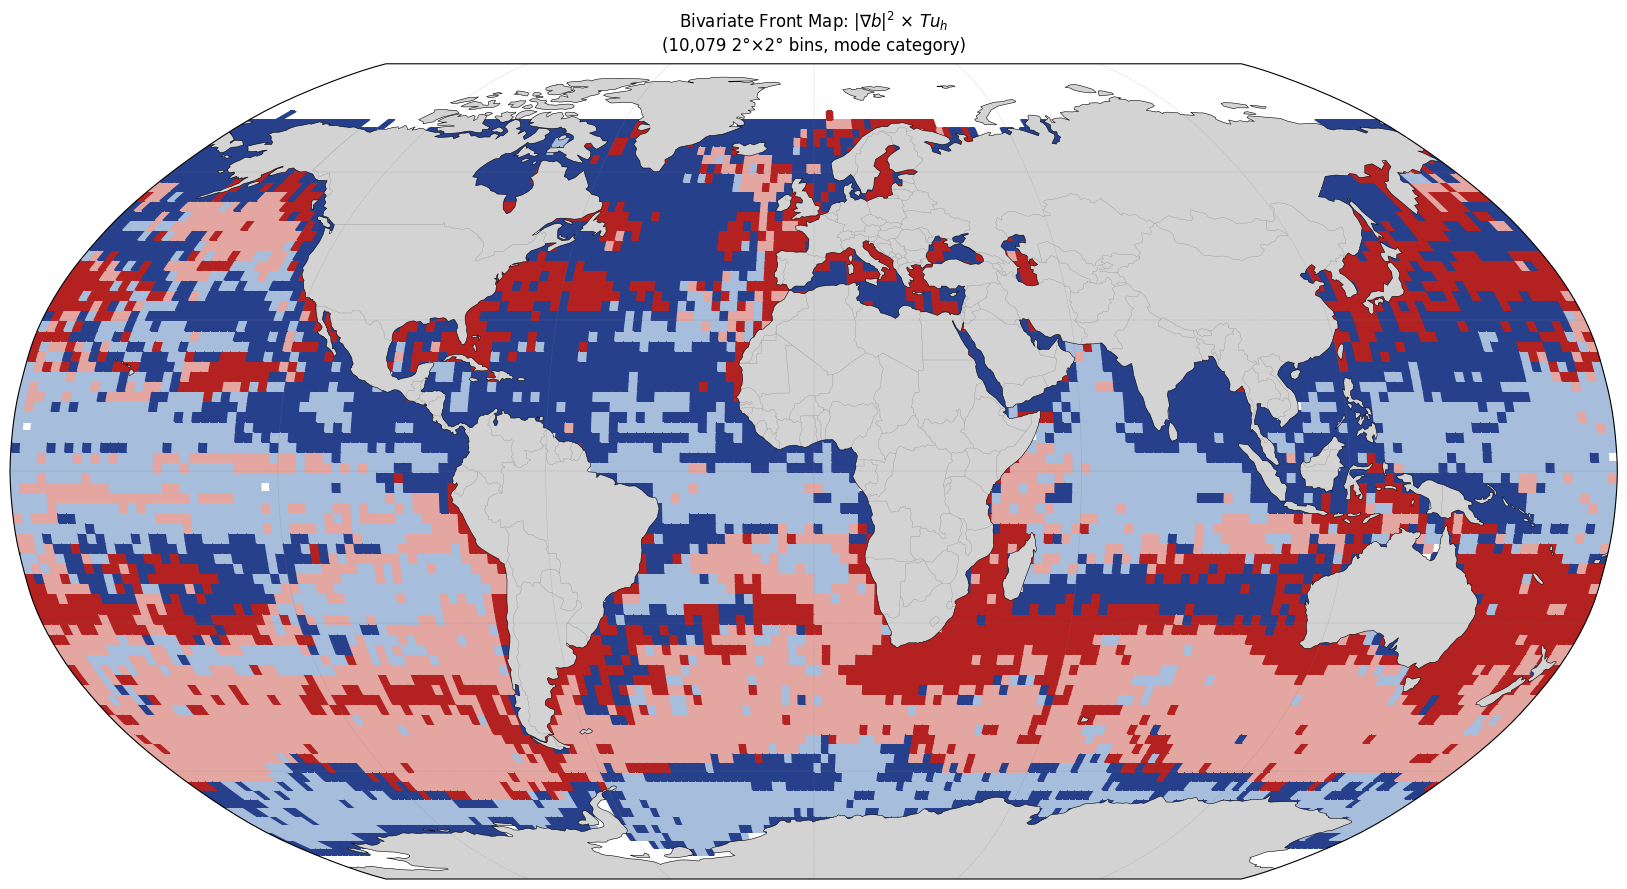

In [30]:
# ─── PLOT 2: BIVARIATE GLOBAL MAP ─────────────────────────────────────────────
fig_map, ax_map = plot_turner_gradb2_map(
    df_enriched, bins_gradb2, bins_turner, color_grid,
    projection=PROJECTION,
    marker_size=MARKER_SIZE,
    use_spatial_binning=USE_SPATIAL_BINNING,
    spatial_bin_deg=SPATIAL_BIN_DEG,
)
plt.show()

In [ ]:
# ─── SAVE FIGURES ─────────────────────────────────────────────────────────────
SAVE_DIR.mkdir(parents=True, exist_ok=True)

tag = f"gradb2_x_turner_{STATISTIC}"

legend_path = SAVE_DIR / f"bivariate_legend_{tag}.png"
fig_legend.savefig(legend_path, dpi=SAVE_DPI, bbox_inches='tight', facecolor='white')
print(f"Saved legend → {legend_path}")

map_path = SAVE_DIR / f"bivariate_map_{tag}.png"
fig_map.savefig(map_path, dpi=SAVE_DPI, bbox_inches='tight', facecolor='white')
print(f"Saved map    → {map_path}")

---
## 6. Quick Experiments

/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


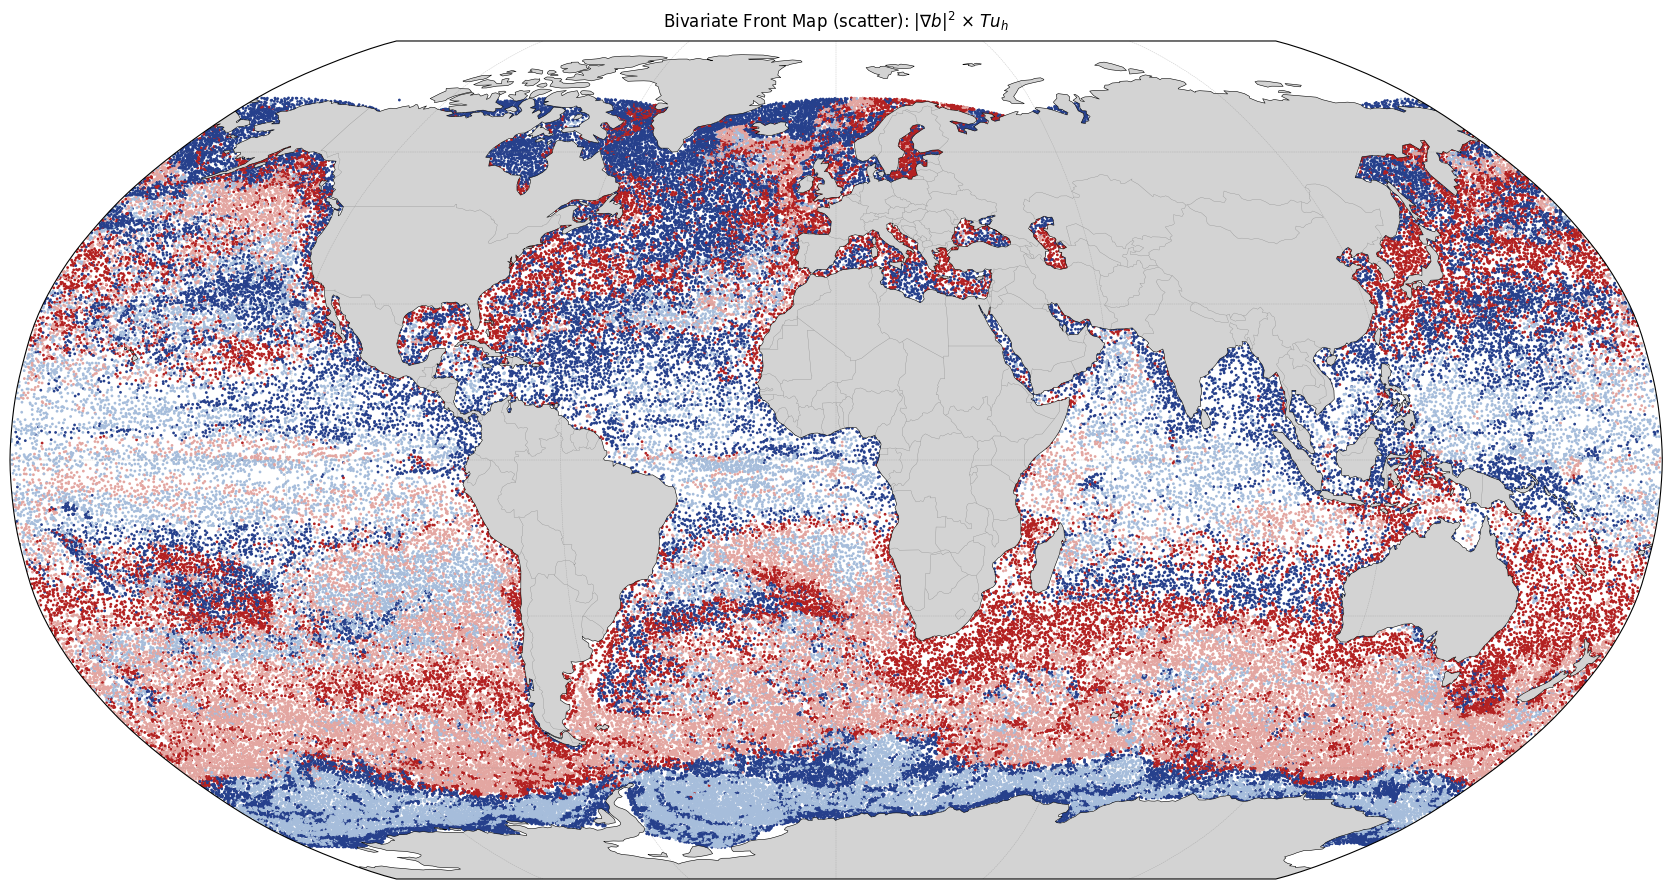

NameError: name 'tag' is not defined

In [31]:
# ─── TRY SCATTER MODE ─────────────────────────────────────────────────────────
fig_sc, ax_sc = plot_turner_gradb2_map(
    df_enriched, bins_gradb2, bins_turner, color_grid,
    projection=PROJECTION,
    marker_size=4,
    use_spatial_binning=False,
    title=r'Bivariate Front Map (scatter): $|\nabla b|^2$ × $Tu_h$',
)
plt.show()

scatter_path = SAVE_DIR / f"bivariate_scatter_{tag}.png"
fig_sc.savefig(scatter_path, dpi=SAVE_DPI, bbox_inches='tight', facecolor='white')
print(f"Saved scatter map → {scatter_path}")